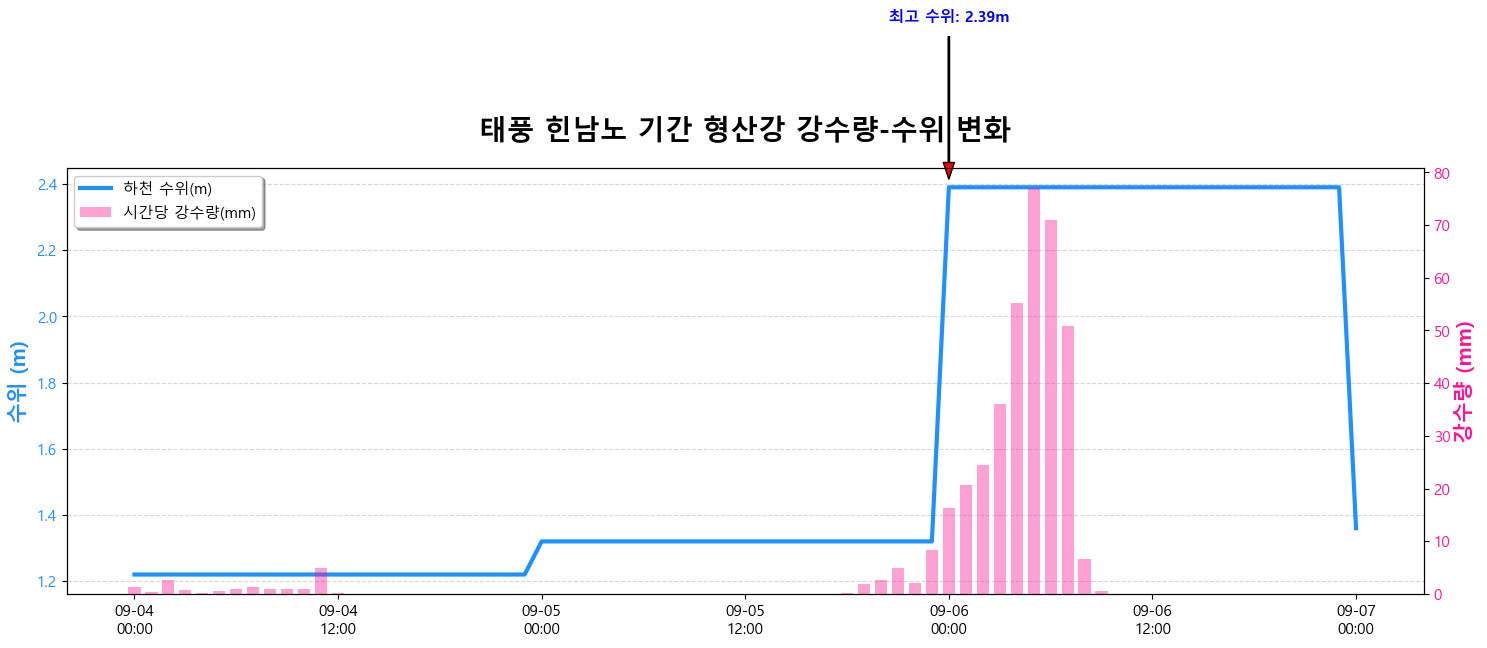

In [71]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

plt.rc('font', family='Malgun Gothic', size=11)
plt.rc('axes', unicode_minus=False)

hinnamno = df_train[(df_train['일시'] >= '2022-09-04') & (df_train['일시'] <= '2022-09-07')]

fig, ax1 = plt.subplots(figsize=(15, 7))

lns1 = ax1.plot(hinnamno['일시'], hinnamno['water_level'], 
                color='dodgerblue', label='하천 수위(m)', linewidth=3, zorder=2)
ax1.set_ylabel('수위 (m)', color='dodgerblue', fontweight='bold', fontsize=15)
ax1.tick_params(axis='y', labelcolor='dodgerblue')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
lns2 = ax2.bar(hinnamno['일시'], hinnamno['강수량(mm)'], 
               color='deeppink', alpha=0.4, label='시간당 강수량(mm)', width=0.03, zorder=1)
ax2.set_ylabel('강수량 (mm)', color='deeppink', fontweight='bold', fontsize=15)
ax2.tick_params(axis='y', labelcolor='deeppink')

ax1.xaxis.set_major_locator(mdates.HourLocator(interval=12)) 
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
plt.xticks(rotation=0) 

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, shadow=True)

max_wl = hinnamno['water_level'].max()
max_time = hinnamno.loc[hinnamno['water_level'].idxmax(), '일시']
ax1.annotate(f'최고 수위: {max_wl}m', xy=(max_time, max_wl), xytext=(max_time, max_wl+0.5),
             arrowprops=dict(facecolor='red', shrink=0.05, width=1, headwidth=8),
             ha='center', fontweight='bold', color='blue')

plt.title('태풍 힌남노 기간 형산강 강수량-수위 변화', fontsize=20, pad=20, fontweight='bold')
fig.tight_layout()
plt.show()

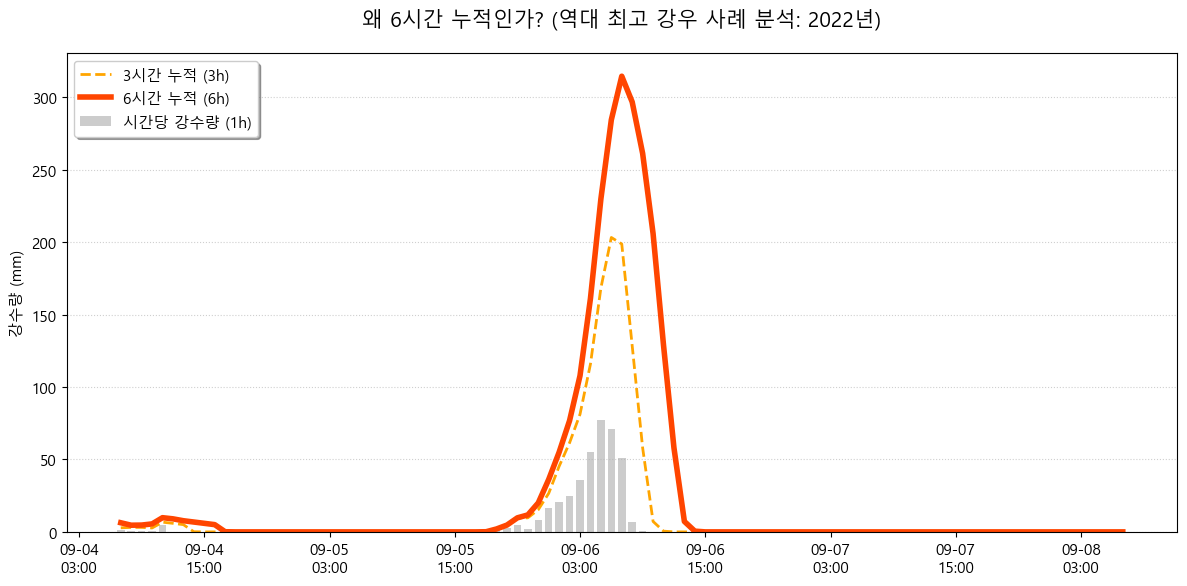

In [72]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

df_train['rain_3h_sum'] = df_train['강수량(mm)'].rolling(window=3).sum()
df_train['rain_6h_sum'] = df_train['강수량(mm)'].rolling(window=6).sum()

max_rain_idx = df_train['rain_6h_sum'].idxmax()
max_rain_date = df_train.loc[max_rain_idx, '일시']

start_date = max_rain_date - pd.Timedelta(days=2)
end_date = max_rain_date + pd.Timedelta(days=2)
analysis_period = df_train[(df_train['일시'] >= start_date) & (df_train['일시'] <= end_date)]

plt.figure(figsize=(12, 6))

plt.bar(analysis_period['일시'], analysis_period['강수량(mm)'], 
        color='grey', alpha=0.4, label='시간당 강수량 (1h)', width=0.03)

plt.plot(analysis_period['일시'], analysis_period['rain_3h_sum'], 
         color='orange', linewidth=2, linestyle='--', label='3시간 누적 (3h)')

plt.plot(analysis_period['일시'], analysis_period['rain_6h_sum'], 
         color='orangered', linewidth=4, label='6시간 누적 (6h)')

plt.title(f'왜 6시간 누적인가? (역대 최고 강우 사례 분석: {max_rain_date.year}년)', fontsize=15, pad=20)
plt.ylabel('강수량 (mm)')
plt.legend(loc='upper left', shadow=True)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=12))

plt.tight_layout()
plt.show()

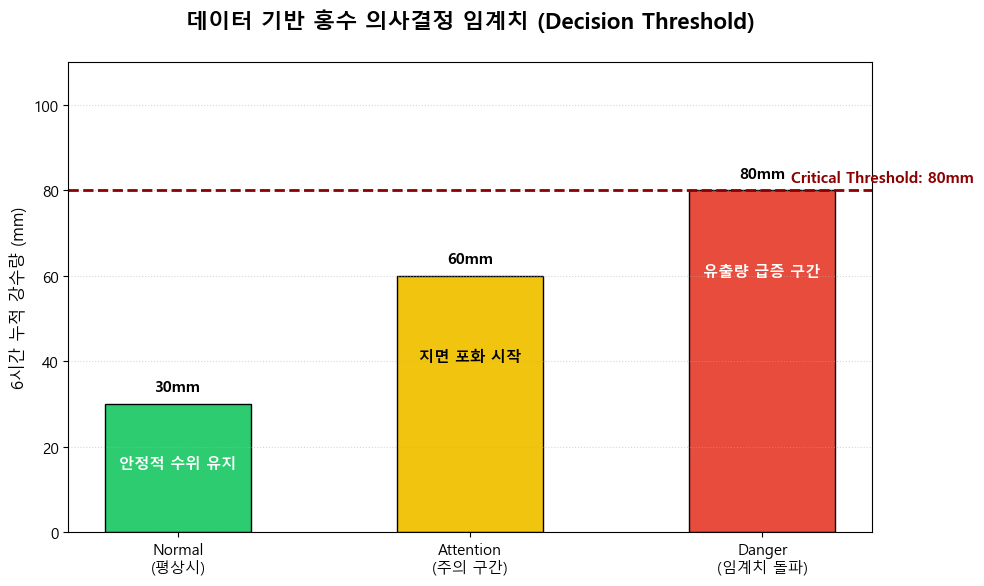

In [73]:
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

stages = ['Normal\n(평상시)', 'Attention\n(주의 구간)', 'Danger\n(임계치 돌파)']
rain_levels = [30, 60, 80] 
colors = ['#2ecc71', '#f1c40f', '#e74c3c'] 

plt.figure(figsize=(10, 6))
bars = plt.bar(stages, rain_levels, color=colors, width=0.5, edgecolor='black', linewidth=1)

plt.axhline(y=80, color='darkred', linestyle='--', linewidth=2)
plt.text(2.1, 82, 'Critical Threshold: 80mm', color='darkred', fontweight='bold')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2, 
             f'{height}mm', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('데이터 기반 홍수 의사결정 임계치 (Decision Threshold)', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('6시간 누적 강수량 (mm)', fontsize=12)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle=':', alpha=0.5)

plt.text(0, 15, '안정적 수위 유지', ha='center', color='white', fontweight='bold')
plt.text(1, 40, '지면 포화 시작', ha='center', color='black', fontweight='bold')
plt.text(2, 60, '유출량 급증 구간', ha='center', color='white', fontweight='bold')

plt.tight_layout()
plt.show()